In [1]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx", sheet_name="Online Retail")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
print(df.shape)
print(df.columns)


(541909, 8)
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
df.isnull().sum()


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df.duplicated().sum()


np.int64(5268)

In [6]:
df_clean = df.drop_duplicates()

print("Original shape:", df.shape)
print("After removing duplicates:", df_clean.shape)


Original shape: (541909, 8)
After removing duplicates: (536641, 8)


In [7]:
df_clean = df_clean.dropna(subset=["Description"])

print("After removing missing Description:", df_clean.shape)


After removing missing Description: (535187, 8)


In [8]:
df_clean = df_clean.dropna(subset=["CustomerID"])

print("After removing missing CustomerID:", df_clean.shape)


After removing missing CustomerID: (401604, 8)


In [9]:
print("Rows with Quantity <= 0:", (df_clean["Quantity"] <= 0).sum())
print("Rows with UnitPrice <= 0:", (df_clean["UnitPrice"] <= 0).sum())


Rows with Quantity <= 0: 8872
Rows with UnitPrice <= 0: 40


In [10]:
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)]

print("After removing invalid Quantity and UnitPrice:", df_clean.shape)


After removing invalid Quantity and UnitPrice: (392692, 8)


In [11]:
df_clean["TotalSales"] = df_clean["Quantity"] * df_clean["UnitPrice"]

df_clean[["Quantity", "UnitPrice", "TotalSales"]].head()


,Quantity,UnitPrice,TotalSales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [12]:
df_clean[["Quantity", "UnitPrice", "TotalSales"]].describe()


,Quantity,UnitPrice,TotalSales
count,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,22.631500
std,180.492832,22.241836,311.099224
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.450000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


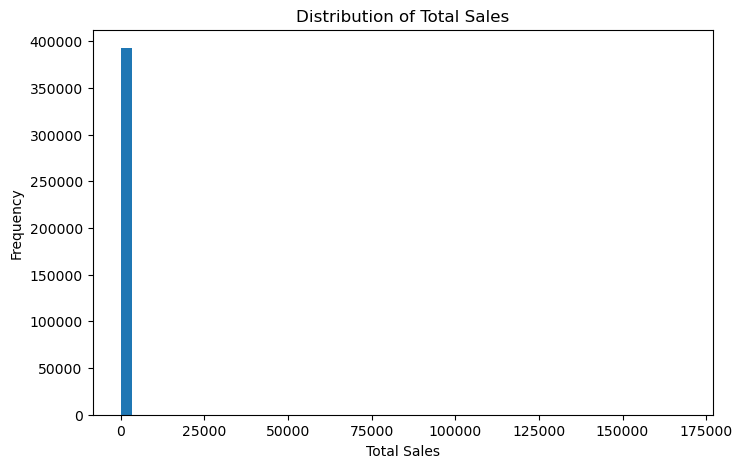

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_clean["TotalSales"], bins=50)
plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.show()


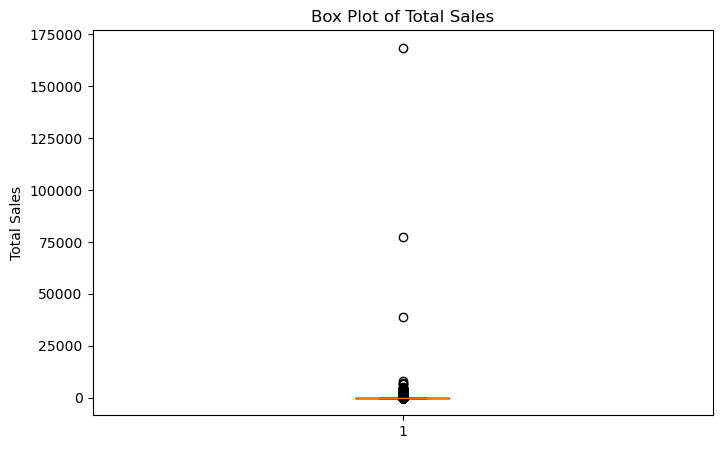

In [14]:
plt.figure(figsize=(8,5))
plt.boxplot(df_clean["TotalSales"])
plt.title("Box Plot of Total Sales")
plt.ylabel("Total Sales")
plt.show()


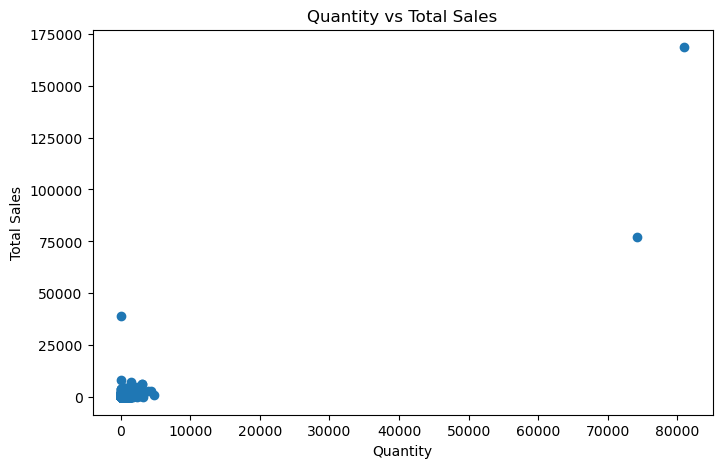

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(df_clean["Quantity"], df_clean["TotalSales"])
plt.title("Quantity vs Total Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")
plt.show()


In [16]:
import numpy as np

df_clean["LogTotalSales"] = np.log1p(df_clean["TotalSales"])

df_clean[["TotalSales", "LogTotalSales"]].head()


,TotalSales,LogTotalSales
0,15.30,2.791165
1,20.34,3.060583
2,22.00,3.135494
3,20.34,3.060583
4,20.34,3.060583


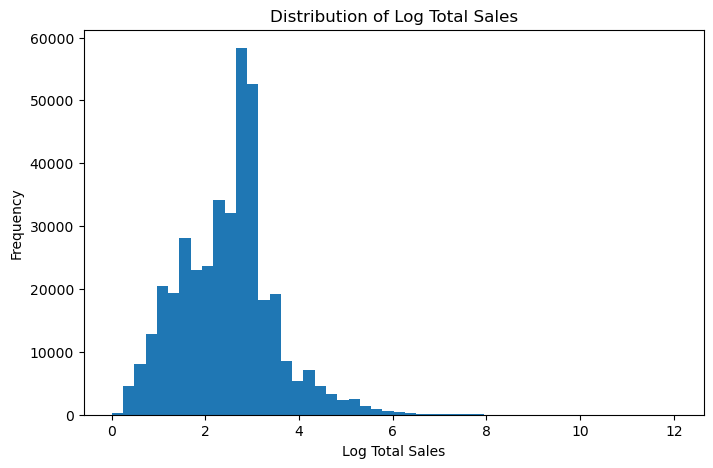

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df_clean["LogTotalSales"], bins=50)
plt.title("Distribution of Log Total Sales")
plt.xlabel("Log Total Sales")
plt.ylabel("Frequency")
plt.show()


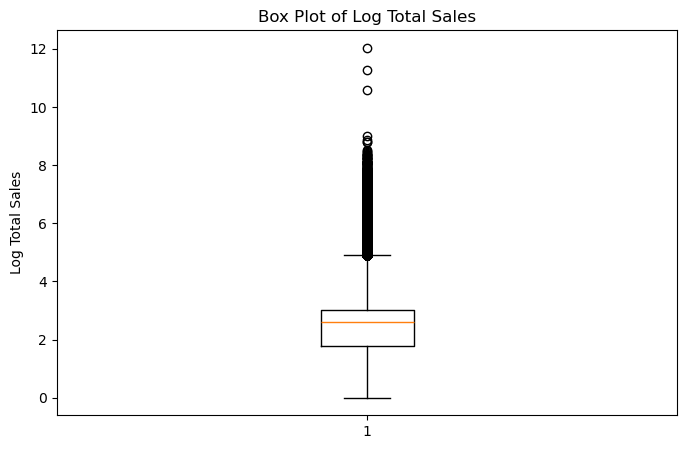

In [18]:
plt.figure(figsize=(8,5))
plt.boxplot(df_clean["LogTotalSales"])
plt.title("Box Plot of Log Total Sales")
plt.ylabel("Log Total Sales")
plt.show()


In [19]:
df_clean["Month"] = df_clean["InvoiceDate"].dt.month

df_clean[["InvoiceDate", "Month"]].head()


,InvoiceDate,Month
0,2010-12-01 08:26:00,12
1,2010-12-01 08:26:00,12
2,2010-12-01 08:26:00,12
3,2010-12-01 08:26:00,12
4,2010-12-01 08:26:00,12


In [20]:
df_clean.groupby("Month")["TotalSales"].sum().sort_index()


Month
1      568101.310
2      446084.920
3      594081.760
4      468374.331
5      677355.150
6      660046.050
7      598962.901
8      644051.040
9      950690.202
10    1035642.450
11    1156205.610
12    1087613.170
Name: TotalSales, dtype: float64

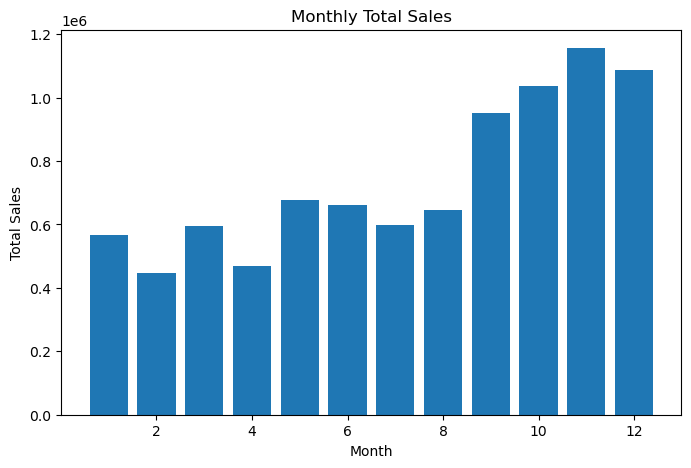

In [21]:
monthly_sales = df_clean.groupby("Month")["TotalSales"].sum().sort_index()

plt.figure(figsize=(8,5))
plt.bar(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Total Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()


In [22]:
country_sales = df_clean.groupby("Country")["TotalSales"].sum().sort_values(ascending=False).head(10)
country_sales


Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalSales, dtype: float64

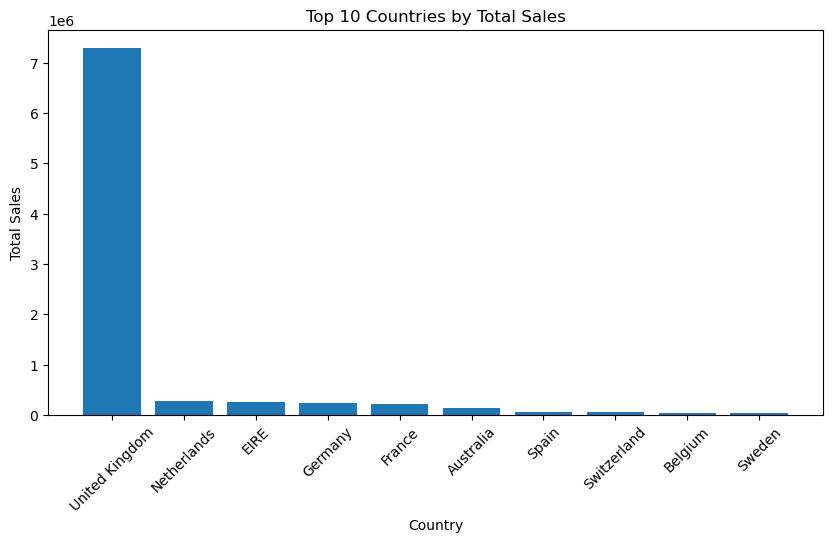

In [23]:
plt.figure(figsize=(10,5))
plt.bar(country_sales.index, country_sales.values)
plt.title("Top 10 Countries by Total Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


In [24]:
customer_df = df_clean.groupby("CustomerID").agg({
    "InvoiceNo": "nunique",
    "Quantity": "sum",
    "UnitPrice": "mean",
    "TotalSales": "sum",
    "Month": "nunique"
}).reset_index()

customer_df.columns = [
    "CustomerID",
    "NumTransactions",
    "TotalQuantity",
    "AvgUnitPrice",
    "TotalSpent",
    "ActiveMonths"
]

customer_df.head()


,CustomerID,NumTransactions,TotalQuantity,AvgUnitPrice,TotalSpent,ActiveMonths
0,12346.0,1,74215,1.040000,77183.60,1
1,12347.0,7,2458,2.644011,4310.00,6
2,12348.0,4,2341,5.764839,1797.24,4
3,12349.0,1,631,8.289041,1757.55,1
4,12350.0,1,197,3.841176,334.40,1


In [25]:
print(customer_df.shape)


(4338, 6)


In [26]:
customer_df.describe()


,CustomerID,NumTransactions,TotalQuantity,AvgUnitPrice,TotalSpent,ActiveMonths
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,4.272015,1187.644537,4.470820,2048.688081,2.955048
std,1721.808492,7.697998,5043.619654,34.215024,8985.230220,2.515904
min,12346.000000,1.000000,1.000000,0.122500,3.750000,1.000000
25%,13813.250000,1.000000,159.000000,2.206415,306.482500,1.000000
50%,15299.500000,2.000000,378.000000,2.917836,668.570000,2.000000
75%,16778.750000,5.000000,989.750000,3.832541,1660.597500,4.000000
max,18287.000000,209.000000,196915.000000,2033.100000,280206.020000,12.000000


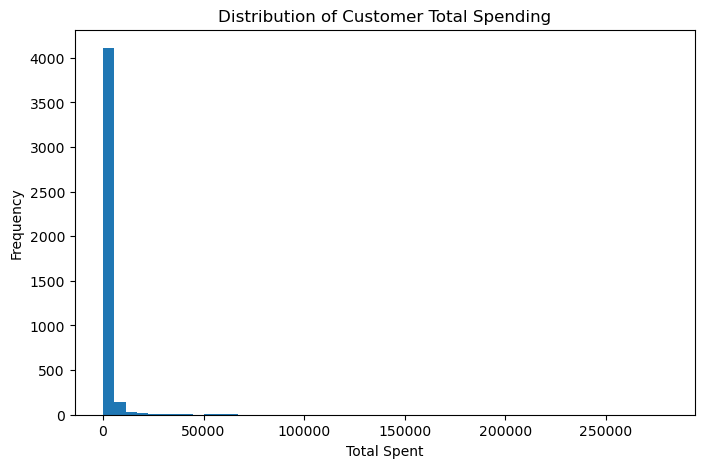

In [27]:
plt.figure(figsize=(8,5))
plt.hist(customer_df["TotalSpent"], bins=50)
plt.title("Distribution of Customer Total Spending")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")
plt.show()


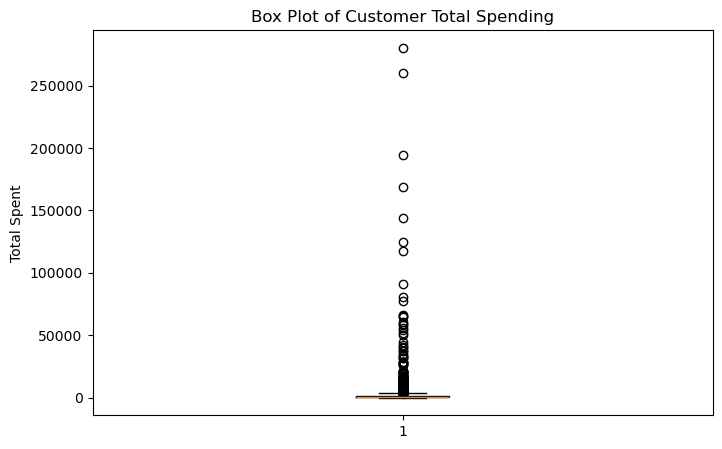

In [28]:
plt.figure(figsize=(8,5))
plt.boxplot(customer_df["TotalSpent"])
plt.title("Box Plot of Customer Total Spending")
plt.ylabel("Total Spent")
plt.show()


In [29]:
customer_df["LogTotalSpent"] = np.log1p(customer_df["TotalSpent"])

customer_df[["TotalSpent", "LogTotalSpent"]].head()


,TotalSpent,LogTotalSpent
0,77183.60,11.253955
1,4310.00,8.368925
2,1797.24,7.494564
3,1757.55,7.472245
4,334.40,5.815324


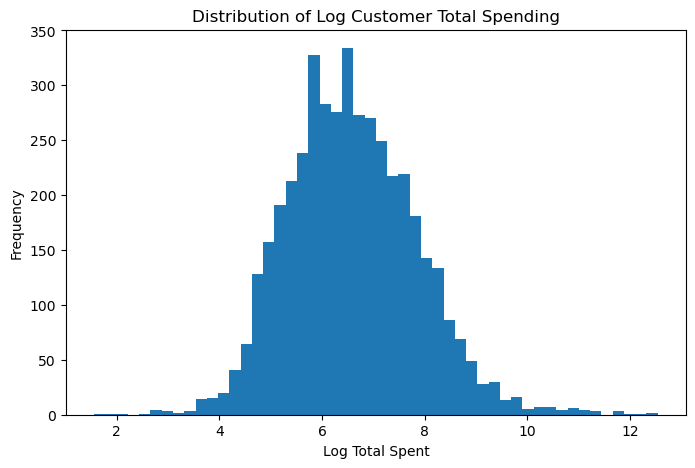

In [30]:
plt.figure(figsize=(8,5))
plt.hist(customer_df["LogTotalSpent"], bins=50)
plt.title("Distribution of Log Customer Total Spending")
plt.xlabel("Log Total Spent")
plt.ylabel("Frequency")
plt.show()


In [31]:
X = customer_df[["NumTransactions", "TotalQuantity", "AvgUnitPrice", "ActiveMonths"]]
y = customer_df["LogTotalSpent"]

print(X.head())
print(y.head())


   NumTransactions  TotalQuantity  AvgUnitPrice  ActiveMonths
0                1          74215      1.040000             1
1                7           2458      2.644011             6
2                4           2341      5.764839             4
3                1            631      8.289041             1
4                1            197      3.841176             1
0    11.253955
1     8.368925
2     7.494564
3     7.472245
4     5.815324
Name: LogTotalSpent, dtype: float64


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (3470, 4)
X_test shape: (868, 4)
y_train shape: (3470,)
y_test shape: (868,)


In [33]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully")


Linear Regression model trained successfully


In [34]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_pred_lr = lr_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))


R2 Score: 0.6338339185305999
MSE: 0.5875569228035921
RMSE: 0.7665226172811811


In [35]:
from sklearn.linear_model import Ridge

ridge_model = Ridge()
ridge_model.fit(X_train, y_train)

print("Ridge Regression model trained successfully")


Ridge Regression model trained successfully


In [36]:
y_pred_ridge = ridge_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_ridge))
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))


R2 Score: 0.6338355048008626
MSE: 0.5875543774447469
RMSE: 0.7665209569507848


In [37]:
regression_results = {
    "Model": ["Linear Regression", "Ridge Regression"],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge)
    ],
    "MSE": [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_ridge)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge))
    ]
}

import pandas as pd
results_df = pd.DataFrame(regression_results)
results_df


,Model,R2,MSE,RMSE
0,Linear Regression,0.633834,0.587557,0.766523
1,Ridge Regression,0.633836,0.587554,0.766521


In [38]:
customer_df["HighValueCustomer"] = (
    customer_df["TotalSpent"] > customer_df["TotalSpent"].median()
).astype(int)

customer_df[["TotalSpent", "HighValueCustomer"]].head()


,TotalSpent,HighValueCustomer
0,77183.60,1
1,4310.00,1
2,1797.24,1
3,1757.55,1
4,334.40,0


In [39]:
customer_df["HighValueCustomer"].value_counts()


HighValueCustomer
1    2169
0    2169
Name: count, dtype: int64

In [40]:
X_cls = customer_df[["NumTransactions", "TotalQuantity", "AvgUnitPrice", "ActiveMonths"]]
y_cls = customer_df["HighValueCustomer"]

print(X_cls.head())
print(y_cls.head())


   NumTransactions  TotalQuantity  AvgUnitPrice  ActiveMonths
0                1          74215      1.040000             1
1                7           2458      2.644011             6
2                4           2341      5.764839             4
3                1            631      8.289041             1
4                1            197      3.841176             1
0    1
1    1
2    1
3    1
4    0
Name: HighValueCustomer, dtype: int64


In [41]:
from sklearn.model_selection import train_test_split

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print("X_train_cls shape:", X_train_cls.shape)
print("X_test_cls shape:", X_test_cls.shape)
print("y_train_cls shape:", y_train_cls.shape)
print("y_test_cls shape:", y_test_cls.shape)


X_train_cls shape: (3470, 4)
X_test_cls shape: (868, 4)
y_train_cls shape: (3470,)
y_test_cls shape: (868,)


In [42]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_cls, y_train_cls)

print("Decision Tree model trained successfully")


Decision Tree model trained successfully


In [43]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

y_pred_dt = dt_model.predict(X_test_cls)

print("Accuracy:", accuracy_score(y_test_cls, y_pred_dt))
print("F1 Score:", f1_score(y_test_cls, y_pred_dt))
print("Confusion Matrix:")
print(confusion_matrix(y_test_cls, y_pred_dt))


Accuracy: 0.9066820276497696
F1 Score: 0.9088863892013498
Confusion Matrix:
[[383  51]
 [ 30 404]]


In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_cls_scaled = scaler.fit_transform(X_train_cls)
X_test_cls_scaled = scaler.transform(X_test_cls)

print("Scaled training data shape:", X_train_cls_scaled.shape)
print("Scaled test data shape:", X_test_cls_scaled.shape)


Scaled training data shape: (3470, 4)
Scaled test data shape: (868, 4)


In [45]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_cls_scaled, y_train_cls)

print("k-NN model trained successfully")


k-NN model trained successfully


In [46]:
y_pred_knn = knn_model.predict(X_test_cls_scaled)

print("Accuracy:", accuracy_score(y_test_cls, y_pred_knn))
print("F1 Score:", f1_score(y_test_cls, y_pred_knn))
print("Confusion Matrix:")
print(confusion_matrix(y_test_cls, y_pred_knn))


Accuracy: 0.9170506912442397
F1 Score: 0.9181818181818182
Confusion Matrix:
[[392  42]
 [ 30 404]]


In [47]:
classification_results = {
    "Model": ["Decision Tree", "k-NN"],
    "Accuracy": [
        accuracy_score(y_test_cls, y_pred_dt),
        accuracy_score(y_test_cls, y_pred_knn)
    ],
    "F1 Score": [
        f1_score(y_test_cls, y_pred_dt),
        f1_score(y_test_cls, y_pred_knn)
    ]
}

classification_results_df = pd.DataFrame(classification_results)
classification_results_df


,Model,Accuracy,F1 Score
0,Decision Tree,0.906682,0.908886
1,k-NN,0.917051,0.918182


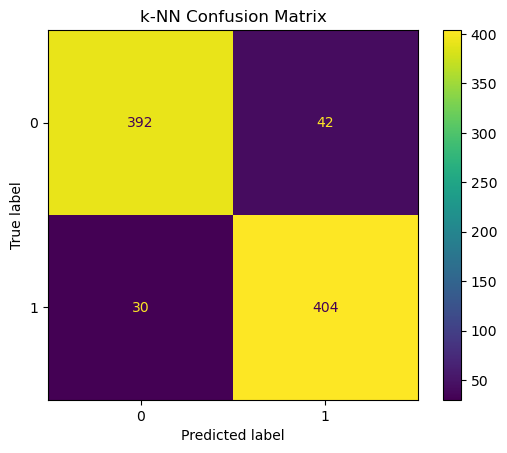

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(knn_model, X_test_cls_scaled, y_test_cls)
plt.title("k-NN Confusion Matrix")
plt.show()


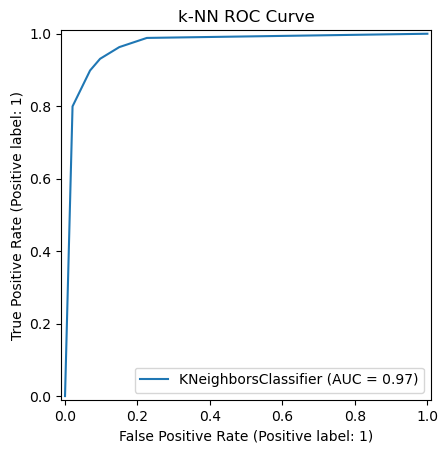

In [49]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(knn_model, X_test_cls_scaled, y_test_cls)
plt.title("k-NN ROC Curve")
plt.show()


In [50]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_cls, y_train_cls)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)


Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score: 0.9272575121139548


In [51]:
best_dt_model = grid_search.best_estimator_

y_pred_best_dt = best_dt_model.predict(X_test_cls)

print("Accuracy:", accuracy_score(y_test_cls, y_pred_best_dt))
print("F1 Score:", f1_score(y_test_cls, y_pred_best_dt))
print("Confusion Matrix:")
print(confusion_matrix(y_test_cls, y_pred_best_dt))


Accuracy: 0.9182027649769585
F1 Score: 0.9204927211646137
Confusion Matrix:
[[386  48]
 [ 23 411]]


In [52]:
final_classification_results = {
    "Model": ["k-NN", "Tuned Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test_cls, y_pred_knn),
        accuracy_score(y_test_cls, y_pred_best_dt)
    ],
    "F1 Score": [
        f1_score(y_test_cls, y_pred_knn),
        f1_score(y_test_cls, y_pred_best_dt)
    ]
}

final_classification_results_df = pd.DataFrame(final_classification_results)
final_classification_results_df


,Model,Accuracy,F1 Score
0,k-NN,0.917051,0.918182
1,Tuned Decision Tree,0.918203,0.920493


In [53]:
cluster_features = customer_df[["NumTransactions", "TotalQuantity", "AvgUnitPrice", "TotalSpent", "ActiveMonths"]]

cluster_scaler = StandardScaler()
cluster_scaled = cluster_scaler.fit_transform(cluster_features)

print(cluster_features.head())
print(cluster_scaled.shape)


   NumTransactions  TotalQuantity  AvgUnitPrice  TotalSpent  ActiveMonths
0                1          74215      1.040000    77183.60             1
1                7           2458      2.644011     4310.00             6
2                4           2341      5.764839     1797.24             4
3                1            631      8.289041     1757.55             1
4                1            197      3.841176      334.40             1
(4338, 5)


In [54]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_df["Cluster"] = kmeans.fit_predict(cluster_scaled)

customer_df[["CustomerID", "TotalSpent", "Cluster"]].head()


,CustomerID,TotalSpent,Cluster
0,12346.0,77183.60,1
1,12347.0,4310.00,2
2,12348.0,1797.24,0
3,12349.0,1757.55,0
4,12350.0,334.40,0


In [55]:
customer_df["Cluster"].value_counts().sort_index()


Cluster
0    3705
1      17
2     616
Name: count, dtype: int64

In [56]:
customer_df.groupby("Cluster")[["NumTransactions", "TotalQuantity", "AvgUnitPrice", "TotalSpent", "ActiveMonths"]].mean()


,NumTransactions,TotalQuantity,AvgUnitPrice,TotalSpent,ActiveMonths
Cluster,,,,,
0,2.453711,520.012686,4.639042,874.653016,2.096086
1,70.352941,64439.176471,4.642714,112579.267647,10.352941
2,13.384740,3457.612013,3.454289,6059.694675,7.917208


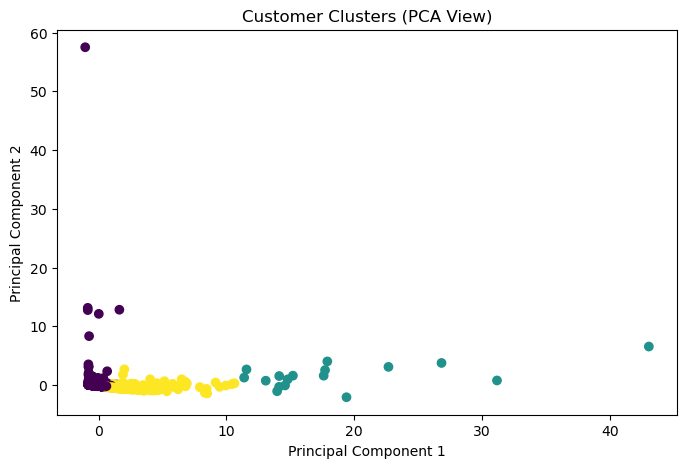

In [57]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
cluster_pca = pca.fit_transform(cluster_scaled)

plt.figure(figsize=(8,5))
plt.scatter(cluster_pca[:, 0], cluster_pca[:, 1], c=customer_df["Cluster"])
plt.title("Customer Clusters (PCA View)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


In [58]:
!pip install mlxtend


   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 1.6 MB/s eta 0:00:01
   ------------------------------ --------- 1.0/1.4 MB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 1.6 MB/s  0:00:01
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 570.7 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/8.1 MB 758.2 kB/s eta 0:00:1

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\users\\devi1\\anaconda3\\lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSans.ttf'
Consider using the `--user` option or check the permissions.



In [1]:
%pip install --user mlxtend


  Using cached mlxtend-0.24.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
Using cached mlxtend-0.24.0-py3-none-any.whl (1.4 MB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)

   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---

In [2]:
from mlxtend.frequent_patterns import apriori, association_rules

top_products = df_clean["Description"].value_counts().head(20).index

basket_df = df_clean[df_clean["Description"].isin(top_products)]

basket = basket_df.groupby(["InvoiceNo", "Description"])["Quantity"].sum().unstack().fillna(0)

basket = basket.apply(lambda x: x > 0).astype(int)

print("Basket shape:", basket.shape)
basket.head()


NameError: name 'df_clean' is not defined

In [3]:
import numpy as np

df_clean = df.drop_duplicates()
df_clean = df_clean.dropna(subset=["Description", "CustomerID"])
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)].copy()

df_clean["TotalSales"] = df_clean["Quantity"] * df_clean["UnitPrice"]
df_clean["LogTotalSales"] = np.log1p(df_clean["TotalSales"])
df_clean["Month"] = df_clean["InvoiceDate"].dt.month

print("df_clean shape:", df_clean.shape)


df_clean shape: (392692, 11)


In [4]:
from mlxtend.frequent_patterns import apriori, association_rules

top_products = df_clean["Description"].value_counts().head(20).index

basket_df = df_clean[df_clean["Description"].isin(top_products)]

basket = basket_df.groupby(["InvoiceNo", "Description"])["Quantity"].sum().unstack().fillna(0)

basket = basket.apply(lambda x: x > 0).astype(int)

print("Basket shape:", basket.shape)
basket.head()


Basket shape: (10776, 20)


Description,ALARM CLOCK BAKELIKE RED,ASSORTED COLOUR BIRD ORNAMENT,HEART OF WICKER SMALL,JUMBO BAG RED RETROSPOT,LUNCH BAG BLACK SKULL.,LUNCH BAG CARS BLUE,LUNCH BAG PINK POLKADOT,LUNCH BAG RED RETROSPOT,LUNCH BAG SPACEBOY DESIGN,LUNCH BAG SUKI DESIGN,NATURAL SLATE HEART CHALKBOARD,PACK OF 72 RETROSPOT CAKE CASES,PAPER CHAIN KIT 50'S CHRISTMAS,PARTY BUNTING,POSTAGE,REGENCY CAKESTAND 3 TIER,REX CASH+CARRY JUMBO SHOPPER,SET OF 3 CAKE TINS PANTRY DESIGN,SPOTTY BUNTING,WHITE HANGING HEART T-LIGHT HOLDER
InvoiceNo,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
536367,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
536370,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
536371,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
536373,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [5]:
frequent_items = apriori(basket, min_support=0.02, use_colnames=True)

print("Frequent itemsets shape:", frequent_items.shape)
frequent_items.head(10)


C:\Users\devi1\AppData\Roaming\Python\Python313\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Frequent itemsets shape: (69, 2)


,support,itemsets
0,0.081385,(ALARM CLOCK BAKELIKE RED )
1,0.127598,(ASSORTED COLOUR BIRD ORNAMENT)
2,0.089180,(HEART OF WICKER SMALL)
3,0.148478,(JUMBO BAG RED RETROSPOT)
4,0.097624,(LUNCH BAG BLACK SKULL.)
5,0.089644,(LUNCH BAG CARS BLUE)
6,0.086396,(LUNCH BAG PINK POLKADOT)
7,0.119525,(LUNCH BAG RED RETROSPOT)
8,0.091685,(LUNCH BAG SPACEBOY DESIGN )
9,0.083426,(LUNCH BAG SUKI DESIGN )


In [6]:
rules = association_rules(frequent_items, metric="lift", min_threshold=1.0)

print("Rules shape:", rules.shape)
rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)


Rules shape: (160, 14)


,antecedents,consequents,support,confidence,lift
0,(REGENCY CAKESTAND 3 TIER),(ASSORTED COLOUR BIRD ORNAMENT),0.021437,0.135643,1.063046
1,(ASSORTED COLOUR BIRD ORNAMENT),(REGENCY CAKESTAND 3 TIER),0.021437,0.168000,1.063046
2,(ASSORTED COLOUR BIRD ORNAMENT),(WHITE HANGING HEART T-LIGHT HOLDER),0.025148,0.197091,1.077550
3,(WHITE HANGING HEART T-LIGHT HOLDER),(ASSORTED COLOUR BIRD ORNAMENT),0.025148,0.137494,1.077550
4,(WHITE HANGING HEART T-LIGHT HOLDER),(HEART OF WICKER SMALL),0.024870,0.135972,1.524693
5,(HEART OF WICKER SMALL),(WHITE HANGING HEART T-LIGHT HOLDER),0.024870,0.278876,1.524693
6,(JUMBO BAG RED RETROSPOT),(LUNCH BAG BLACK SKULL.),0.025241,0.170000,1.741369
7,(LUNCH BAG BLACK SKULL.),(JUMBO BAG RED RETROSPOT),0.025241,0.258555,1.741369
8,(JUMBO BAG RED RETROSPOT),(LUNCH BAG CARS BLUE),0.023756,0.160000,1.784845
9,(LUNCH BAG CARS BLUE),(JUMBO BAG RED RETROSPOT),0.023756,0.265010,1.784845


In [7]:
top_rules = rules[["antecedents", "consequents", "support", "confidence", "lift"]].sort_values(
    by="lift", ascending=False
)

top_rules.head(10)


,antecedents,consequents,support,confidence,lift
62,(LUNCH BAG PINK POLKADOT),"(LUNCH BAG BLACK SKULL., LUNCH BAG CARS BLUE)",0.024128,0.279270,7.148240
59,"(LUNCH BAG BLACK SKULL., LUNCH BAG CARS BLUE)",(LUNCH BAG PINK POLKADOT),0.024128,0.617577,7.148240
121,(LUNCH BAG PINK POLKADOT),"(LUNCH BAG CARS BLUE, LUNCH BAG RED RETROSPOT)",0.025891,0.299678,7.050934
120,"(LUNCH BAG CARS BLUE, LUNCH BAG RED RETROSPOT)",(LUNCH BAG PINK POLKADOT),0.025891,0.609170,7.050934
83,"(LUNCH BAG BLACK SKULL., LUNCH BAG RED RETROS...",(LUNCH BAG PINK POLKADOT),0.028582,0.595745,6.895537
86,(LUNCH BAG PINK POLKADOT),"(LUNCH BAG BLACK SKULL., LUNCH BAG RED RETROS...",0.028582,0.330827,6.895537
125,"(LUNCH BAG PINK POLKADOT, LUNCH BAG SPACEBOY D...",(LUNCH BAG CARS BLUE),0.020601,0.604905,6.747880
128,(LUNCH BAG CARS BLUE),"(LUNCH BAG PINK POLKADOT, LUNCH BAG SPACEBOY D...",0.020601,0.229814,6.747880
126,"(LUNCH BAG CARS BLUE, LUNCH BAG SPACEBOY DESIGN )",(LUNCH BAG PINK POLKADOT),0.020601,0.567775,6.571797
127,(LUNCH BAG PINK POLKADOT),"(LUNCH BAG CARS BLUE, LUNCH BAG SPACEBOY DESIGN )",0.020601,0.238453,6.571797


In [8]:
top_rules_clean = top_rules.copy()

top_rules_clean["antecedents"] = top_rules_clean["antecedents"].apply(lambda x: ", ".join(list(x)))
top_rules_clean["consequents"] = top_rules_clean["consequents"].apply(lambda x: ", ".join(list(x)))

top_rules_clean.head(10)


,antecedents,consequents,support,confidence,lift
62,LUNCH BAG PINK POLKADOT,"LUNCH BAG BLACK SKULL., LUNCH BAG CARS BLUE",0.024128,0.279270,7.148240
59,"LUNCH BAG BLACK SKULL., LUNCH BAG CARS BLUE",LUNCH BAG PINK POLKADOT,0.024128,0.617577,7.148240
121,LUNCH BAG PINK POLKADOT,"LUNCH BAG CARS BLUE, LUNCH BAG RED RETROSPOT",0.025891,0.299678,7.050934
120,"LUNCH BAG CARS BLUE, LUNCH BAG RED RETROSPOT",LUNCH BAG PINK POLKADOT,0.025891,0.609170,7.050934
83,"LUNCH BAG BLACK SKULL., LUNCH BAG RED RETROSPOT",LUNCH BAG PINK POLKADOT,0.028582,0.595745,6.895537
86,LUNCH BAG PINK POLKADOT,"LUNCH BAG BLACK SKULL., LUNCH BAG RED RETROSPOT",0.028582,0.330827,6.895537
125,"LUNCH BAG PINK POLKADOT, LUNCH BAG SPACEBOY DE...",LUNCH BAG CARS BLUE,0.020601,0.604905,6.747880
128,LUNCH BAG CARS BLUE,"LUNCH BAG PINK POLKADOT, LUNCH BAG SPACEBOY DE...",0.020601,0.229814,6.747880
126,"LUNCH BAG CARS BLUE, LUNCH BAG SPACEBOY DESIGN",LUNCH BAG PINK POLKADOT,0.020601,0.567775,6.571797
127,LUNCH BAG PINK POLKADOT,"LUNCH BAG CARS BLUE, LUNCH BAG SPACEBOY DESIGN",0.020601,0.238453,6.571797


In [9]:
best_regression = results_df.sort_values(by="R2", ascending=False).iloc[0]
best_classification = final_classification_results_df.sort_values(by="F1 Score", ascending=False).iloc[0]
best_rule = top_rules_clean.iloc[0]

project_summary = pd.DataFrame({
    "Section": ["Best Regression Model", "Best Classification Model", "Top Association Rule"],
    "Result": [
        f"{best_regression['Model']} | R2={best_regression['R2']:.4f} | RMSE={best_regression['RMSE']:.4f}",
        f"{best_classification['Model']} | Accuracy={best_classification['Accuracy']:.4f} | F1={best_classification['F1 Score']:.4f}",
        f"{best_rule['antecedents']} -> {best_rule['consequents']} | Lift={best_rule['lift']:.4f}"
    ]
})

project_summary


NameError: name 'results_df' is not defined

In [10]:
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, f1_score
import numpy as np

project_summary = pd.DataFrame({
    "Section": [
        "Best Regression Model",
        "Best Classification Model",
        "Top Association Rule"
    ],
    "Result": [
        f"Ridge Regression | R2={r2_score(y_test, y_pred_ridge):.4f} | RMSE={np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f}",
        f"Tuned Decision Tree | Accuracy={accuracy_score(y_test_cls, y_pred_best_dt):.4f} | F1={f1_score(y_test_cls, y_pred_best_dt):.4f}",
        f"{top_rules_clean.iloc[0]['antecedents']} -> {top_rules_clean.iloc[0]['consequents']} | Lift={top_rules_clean.iloc[0]['lift']:.4f}"
    ]
})

project_summary


NameError: name 'y_test' is not defined

In [11]:
project_summary = pd.DataFrame({
    "Section": [
        "Best Regression Model",
        "Best Classification Model",
        "Top Association Rule"
    ],
    "Result": [
        "Ridge Regression | R2=0.6338 | RMSE=0.7665",
        "Tuned Decision Tree | Accuracy=0.9182 | F1=0.9205",
        f"{top_rules_clean.iloc[0]['antecedents']} -> {top_rules_clean.iloc[0]['consequents']} | Lift={top_rules_clean.iloc[0]['lift']:.4f}"
    ]
})

project_summary


,Section,Result
0,Best Regression Model,Ridge Regression | R2=0.6338 | RMSE=0.7665
1,Best Classification Model,Tuned Decision Tree | Accuracy=0.9182 | F1=0.9205
2,Top Association Rule,LUNCH BAG PINK POLKADOT -> LUNCH BAG BLACK SK...
